<a href="https://colab.research.google.com/github/slover1126/slover1126/blob/main/%ED%95%B8%EC%A6%88%EC%98%A8_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D_6%EC%9E%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**6장 결정트리**

**6.1 결정트리 학습과 시각화**

In [7]:
 #결정 트리를 이해하기 위한 모델 학습

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris(as_frame=True)
X_iris = iris.data[["petal length (cm)", "petal width (cm)"]].values
#print(X_iris)
y_iris = iris.target
#print(y_iris)

tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_iris, y_iris)

DecisionTreeClassifier(max_depth=2, random_state=42)

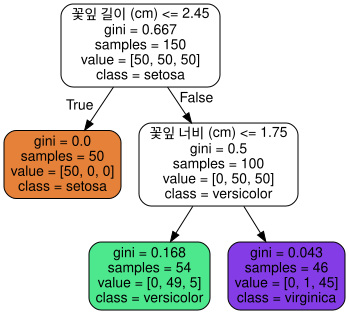

In [11]:
#시각화
from sklearn.tree import export_graphviz
from graphviz import Source
export_graphviz(
    tree_clf,
    out_file="iris_tree.dot",
    feature_names=["꽃잎 길이 (cm)","꽃잎 너비 (cm)"],
    class_names=iris.target_names,
    rounded=True, #노드 상자들 모양을 둥글게 깎아줌 (보기 이쁘게 만)
    filled=True #노드 상자에 색을 채워줌
)

Source.from_file("iris_tree.dot")

**6.2 예측**

*   앞서 학습한 트리를 해석
*    맨 위에 있는 상자를 **루트 노드** 라고 부르고, '꽃잎 길이 (cm) <= 2.45' 라는 조건을 걸어서 데이터들을 1차로 분류함
* 이때 '꽃잎 길이 (cm) <= 2.45' 가 True인 애들은 왼쪽 상자로 이동하고, 추가적인 탐색 조건이 없으므로 **리프 노드** 가 됨
*  한편,  False인 애들은 오른쪽 상자로 이동(깊이 = 1)되어 새로운 조건인 '꽃잎 너비 (cm) <= 1.75' 로 분류하고, 이떄 오른쪽 상자를 **분할 노드** 라고 함

*   다시 '꽃잎 너비 (cm) <= 1.75' 조건이 True 라면 왼쪽 상자로, False라면 오른쪽 상자로 분류함(이떄는 두 상자 모두 **리프 노드**가 됨)











*   위의 그림에서 **samples** 는 얼마나 많은 샘플들이 해당 노드에 들어있는지를 보여줌
*  **values**는 각 클래스별로 몇개의 샘플이 해당 노드에 들어있는지를 보여줌(루트노드의 values = [50,50,50]은 0,1,2번 클래스 모두 50개씩 들어있음을 의미)



*   맨 위의 **gini**는 지니 불순도를 측정한 값이고, 다음과 같이 계산됨
$$G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2$$

*   $G_i$: 노드 $i$의 지니 불순도
*   $n$: 전체 클래스의 개수
*   $p_{i,k}$: 노드 $i$에 속한 전체 샘플 중 클래스 $k$에 속하는 샘플의 비율
*   한 노드 안의 샘플이 모두 같은 클래스인 경우 지니 불순도는 0임


*   예시) 깊이2 의 왼쪽 노드의 지니 불순도는 1-$(0/54)^2$-$(49/54)^2$-$(5/54)^2$ = 0.168 이 됨  
*   사이킷런은 이진 트리만 만드는 CART 알고리즘을 사용함(두 개의 자식 노드만 만듦). ID3 알고리즘은 둘 이상의 자식 노드를 만들 수 있음


*   직관적이고 결정방식을 이해하기 쉽기 떄문에 결정 트리는 **화이트박스 모델**  이라고 불림.










**6.3 클래스 확률 추정**


*   결정 트리는 한 샘플이 특정 클래스 $k$에 속할 확률을 추정할 수도 있음


In [14]:
#'꽃잎 길이' 5cm, '꽃잎 너비' 1.5cm 샘플에 대한 클래스별 확률 추정
tree_clf.predict_proba([[5,1.5]]).round(3)
#이는 깊이 2의 왼쪽 노드에 해당하므로 해당 리프 내에서의 확률 (0번 클래스:0/54(=0%), 1번 클래스:49/54(=90.7%), 2번 클래스: 5/54(=9.3%)) 를 출력

array([[0.   , 0.907, 0.093]])

In [16]:
#'꽃잎 길이' 5cm, '꽃잎 너비' 1.5cm 샘플에 대한 가장 높은 클래스 확률 추정
tree_clf.predict([[5,1.5]])
#확률이 가장 높았던 1번 클래스로 분류

array([1])